In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.FlamingoBaryonResponseEmulator_cosmology import FlamingoBaryonResponseCorrection

import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [2]:
# Cosmology parameters - fiducial FLAMINGO cosmology
H0 =  68.1
h = H0/100.
sigma8 = 0.807
Omega_cdm0 = (0.306-0.0486)
omch2 = Omega_cdm0*h**2 
Omega_b0 = 0.0486 
ombh2 = Omega_b0*h**2 
Omega_k0 = 0.
w = -1.
wa = 0.
ns = 0.967
mnu = 0.06
As=2.099e-9
Tcmb = 2.7255
Neff = 3.046
YHe = 0.248

In [3]:
# redshift and wavenumbers
z = np.array([0.])
ks = np.logspace(np.log10(10**-4), np.log10(10**1.5), 100) #h/Mpc

Text(0.5, 1.0, 'Baryonic suppression of the matter power spectrum')

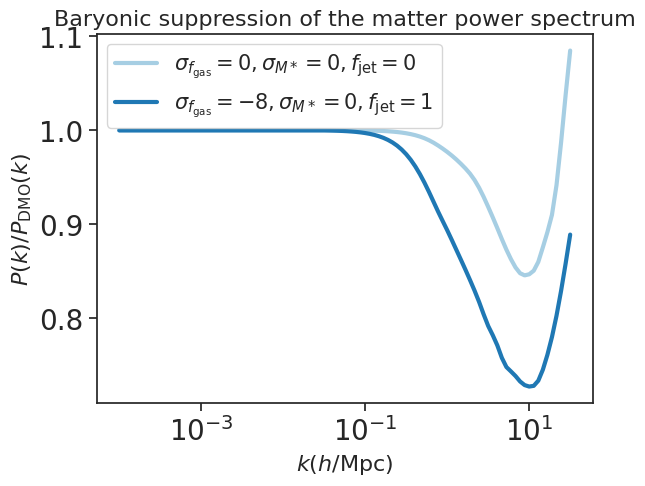

In [4]:
# Baryonic suppression prediction from FLAMINGO, fiducial and strong feedback
baryon_correction_flamingo = FlamingoBaryonResponseCorrection()
fgas_sigma_fid, Mstar_sigma_fid,jet_fraction_fid = 0,0,0 
fiducial_feedback =  baryon_correction_flamingo.predict(z[0],ks,fgas_sigma_fid,Mstar_sigma_fid,jet_fraction_fid)

fgas_sigma_strong, Mstar_sigma_strong,jet_fraction_strong = -8,0,1 
strong_feedback =  baryon_correction_flamingo.predict(z[0],ks,fgas_sigma_strong,Mstar_sigma_strong,jet_fraction_strong)

plt.semilogx(ks, fiducial_feedback, label= fr'$\sigma_{{f_\mathrm{{gas}}}} = {fgas_sigma_fid}, \sigma_{{M*}} = {Mstar_sigma_fid}, f_\mathrm{{jet}} = {jet_fraction_fid}$')
plt.semilogx(ks, strong_feedback, label= fr'$\sigma_{{f_\mathrm{{gas}}}} = {fgas_sigma_strong}, \sigma_{{M*}} = {Mstar_sigma_strong}, f_\mathrm{{jet}} = {jet_fraction_strong}$')
plt.xlabel(r'$k (h/$Mpc)', fontsize = 16)
plt.ylabel(r'$P(k) / P_\mathrm{DMO}(k)$', fontsize = 16)
plt.legend(fontsize = 15)
plt.title("Baryonic suppression of the matter power spectrum", fontsize = 16)

In [5]:
#CAMB + Halofit matter power spectrum 
camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, w0=-1.0, wa=0.0, 
                               gamma_MG=0.0)
                                                   
# CAMB PERTURBATIONS
camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=z, 
                                            nonlinear_model='takahashi')

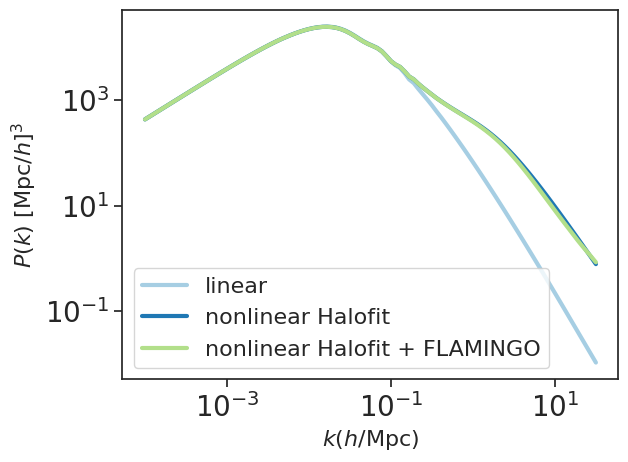

In [6]:
linear_pk_camb = camb_linear.matter_power_spectrum(z, ks, k_hunit=True,hubble_units=True)
nonlinear_pk_camb = camb_nonlinear.matter_power_spectrum(z, ks, k_hunit=True,hubble_units=True)
plt.loglog(ks, linear_pk_camb[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_camb[0, :], label= 'nonlinear Halofit')
plt.loglog(ks, nonlinear_pk_camb[0, :]*fiducial_feedback, label= 'nonlinear Halofit + FLAMINGO')
plt.xlabel(r'$k (h/$Mpc)', fontsize = 16)
plt.ylabel(r'$P(k)$ [Mpc$/h$]$^{3}$', fontsize = 16)
plt.legend(fontsize = 16)